# Credit Risk Default Prediction

**Goal**: Build a model to predict loan defaults using Home Credit data

**Dataset**: 307k applications, ~8% default rate

---

## Plan:
1. Load data & quick look
2. Handle missing values
3. Feature engineering
4. Try a few models
5. Deal with class imbalance
6. Tune best model

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# set random seed for reproducibility
np.random.seed(42)

## 1. Load & Explore

In [17]:
# load data
df = pd.read_csv('../data/application_train.csv')
print(f"Shape: {df.shape}")
print(f"\nDefault rate: {df['TARGET'].mean():.2%}")

Shape: (307511, 122)

Default rate: 8.07%


In [18]:
# check first few rows
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
# missing values - lots of them
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Top 10 columns with missing values:")
print(missing.head(10))

Top 10 columns with missing values:
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
dtype: float64


In [20]:
# data types
print(f"Numeric: {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Categorical: {df.select_dtypes(exclude=[np.number]).shape[1]}")

Numeric: 106
Categorical: 16


## 2. Data Cleaning

Strategy:
- Keep only numeric (easier to start)
- Drop columns with >40% missing
- Fill rest with median

In [21]:
# keep numeric only
df_num = df.select_dtypes(include=[np.number]).copy()
print(f"Numeric columns: {df_num.shape[1]}")

Numeric columns: 106


In [22]:
# drop high missing columns
missing_pct = df_num.isnull().sum() / len(df_num) * 100
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >40% missing")

df_clean = df_num.drop(columns=cols_to_drop)
print(f"Remaining: {df_clean.shape[1]} columns")

Dropping 45 columns with >40% missing
Remaining: 61 columns


In [23]:
# fill remaining missing with median
# important: use .copy() and assign back to avoid issues
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"Missing values after fill: {df_clean.isnull().sum().sum()}")

Missing values after fill: 0


## 3. Feature Engineering

Create some domain features based on what makes sense for credit risk

In [24]:
# age in years (DAYS_BIRTH is negative)
df_clean['age_years'] = df_clean['DAYS_BIRTH'] / -365

# employment years
df_clean['employment_years'] = np.where(
    df_clean['DAYS_EMPLOYED'] < 0,
    df_clean['DAYS_EMPLOYED'] / -365,
    0
)

# income per family member
df_clean['income_per_person'] = df_clean['AMT_INCOME_TOTAL'] / df_clean['CNT_FAM_MEMBERS'].clip(lower=1)

# payment to credit ratio
df_clean['annuity_to_credit'] = df_clean['AMT_ANNUITY'] / df_clean['AMT_CREDIT'].clip(lower=1)

# credit to income ratio
df_clean['credit_to_income'] = df_clean['AMT_CREDIT'] / df_clean['AMT_INCOME_TOTAL']

print("Created 5 new features")

Created 5 new features


In [25]:
# external source features - these look important
# note: EXT_SOURCE_1 was dropped (too much missing), so using 2 and 3

ext_cols = [c for c in ['EXT_SOURCE_2', 'EXT_SOURCE_3'] if c in df_clean.columns]
print(f"Available EXT_SOURCE columns: {ext_cols}")

if len(ext_cols) > 0:
    # weighted average - give more weight to EXT_SOURCE_2 (usually stronger predictor)
    df_clean['ext_source_weighted'] = (
        0.6 * df_clean['EXT_SOURCE_2'].fillna(0) + 
        0.4 * df_clean['EXT_SOURCE_3'].fillna(0)
    )
    
    df_clean['ext_source_mean'] = df_clean[ext_cols].mean(axis=1)
    df_clean['ext_source_min'] = df_clean[ext_cols].min(axis=1)
    df_clean['ext_source_std'] = df_clean[ext_cols].std(axis=1)
    
    print("Created 4 EXT_SOURCE features")

Available EXT_SOURCE columns: ['EXT_SOURCE_2', 'EXT_SOURCE_3']
Created 4 EXT_SOURCE features


In [26]:
# time-based features
df_clean['days_id_published_yr'] = df_clean['DAYS_ID_PUBLISH'] / -365
df_clean['phone_change_yr'] = df_clean['DAYS_LAST_PHONE_CHANGE'] / -365

# fill any new NaNs from feature engineering
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"\nFinal feature count: {df_clean.shape[1]}")
print(f"Any remaining NaNs: {df_clean.isnull().sum().sum()}")


Final feature count: 72
Any remaining NaNs: 0


## 4. Train/Test Split

In [27]:
# separate features and target
y = df_clean['TARGET'].copy()
X = df_clean.drop(columns=['TARGET']).copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nAny NaNs in X: {X.isnull().sum().sum()}")
print(f"Any NaNs in y: {y.isnull().sum()}")

X shape: (307511, 71)
y shape: (307511,)

Any NaNs in X: 0
Any NaNs in y: 0


In [28]:
# 80/20 split, stratify to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")
print(f"\nTrain default rate: {y_train.mean():.2%}")
print(f"Test default rate: {y_test.mean():.2%}")

Train: (246008, 71)
Test: (61503, 71)

Train default rate: 8.07%
Test default rate: 8.07%


## 5. Baseline Model - Logistic Regression

Start simple to get a baseline

In [29]:
# scale features for LR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
# train LR with balanced class weights
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)

# predict
y_pred_lr = lr.predict_proba(X_test_scaled)[:, 1]

# evaluate
lr_auc = roc_auc_score(y_test, y_pred_lr)
print(f"Logistic Regression AUC: {lr_auc:.4f}")

Logistic Regression AUC: 0.7346


## 6. XGBoost Model

Tree-based models usually work better for this type of data

In [31]:
# calculate scale_pos_weight for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 11.39


In [32]:
# train xgboost
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)

xgb.fit(X_train, y_train)

# predict
y_pred_xgb = xgb.predict_proba(X_test)[:, 1]

# evaluate
xgb_auc = roc_auc_score(y_test, y_pred_xgb)
print(f"XGBoost AUC: {xgb_auc:.4f}")
print(f"Improvement over LR: {xgb_auc - lr_auc:.4f}")

XGBoost AUC: 0.7576
Improvement over LR: 0.0229


In [33]:
# check classification report
y_pred_class = (y_pred_xgb >= 0.5).astype(int)
print(classification_report(y_test, y_pred_class, target_names=['Non-Default', 'Default']))

              precision    recall  f1-score   support

 Non-Default       0.96      0.72      0.82     56538
     Default       0.17      0.65      0.27      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.72      0.78     61503



## 7. Handle Class Imbalance with SMOTE

Recall on default class is low (~66%). Let's try SMOTE to improve it.

In [34]:
from imblearn.over_sampling import SMOTE

# apply SMOTE to training data only
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {X_train.shape}")
print(f"After SMOTE: {X_train_smote.shape}")
print(f"\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE: (246008, 71)
After SMOTE: (293992, 71)

Class distribution after SMOTE:
TARGET
0    226148
1     67844
Name: count, dtype: int64


In [35]:
# retrain xgboost on SMOTE data
xgb_smote = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)

xgb_smote.fit(X_train_smote, y_train_smote)

# predict on original test set
y_pred_smote = xgb_smote.predict_proba(X_test)[:, 1]

# evaluate
smote_auc = roc_auc_score(y_test, y_pred_smote)
print(f"XGBoost + SMOTE AUC: {smote_auc:.4f}")

XGBoost + SMOTE AUC: 0.7450


In [36]:
# check if recall improved
y_pred_smote_class = (y_pred_smote >= 0.5).astype(int)
print(classification_report(y_test, y_pred_smote_class, target_names=['Non-Default', 'Default']))

              precision    recall  f1-score   support

 Non-Default       0.96      0.66      0.78     56538
     Default       0.15      0.71      0.25      4965

    accuracy                           0.66     61503
   macro avg       0.56      0.68      0.52     61503
weighted avg       0.90      0.66      0.74     61503



**Note**: SMOTE improved recall from ~66% to ~70% but AUC dropped slightly (0.758 → 0.744). This is expected - SMOTE adds synthetic samples which can introduce noise. For credit risk, catching more defaults is worth the small AUC drop.

## 8. Feature Importance

What drives defaults?

In [37]:
# get feature importance from xgboost
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_smote.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 features:")
print(importance.head(10))

Top 10 features:
                       feature  importance
59  AMT_REQ_CREDIT_BUREAU_YEAR    0.078388
30    DEF_30_CNT_SOCIAL_CIRCLE    0.065929
29    OBS_30_CNT_SOCIAL_CIRCLE    0.062202
15                  FLAG_PHONE    0.060239
66             ext_source_mean    0.058735
58   AMT_REQ_CREDIT_BUREAU_QRT    0.054348
57   AMT_REQ_CREDIT_BUREAU_MON    0.047612
67              ext_source_min    0.042663
31    OBS_60_CNT_SOCIAL_CIRCLE    0.041694
26     LIVE_CITY_NOT_WORK_CITY    0.038472


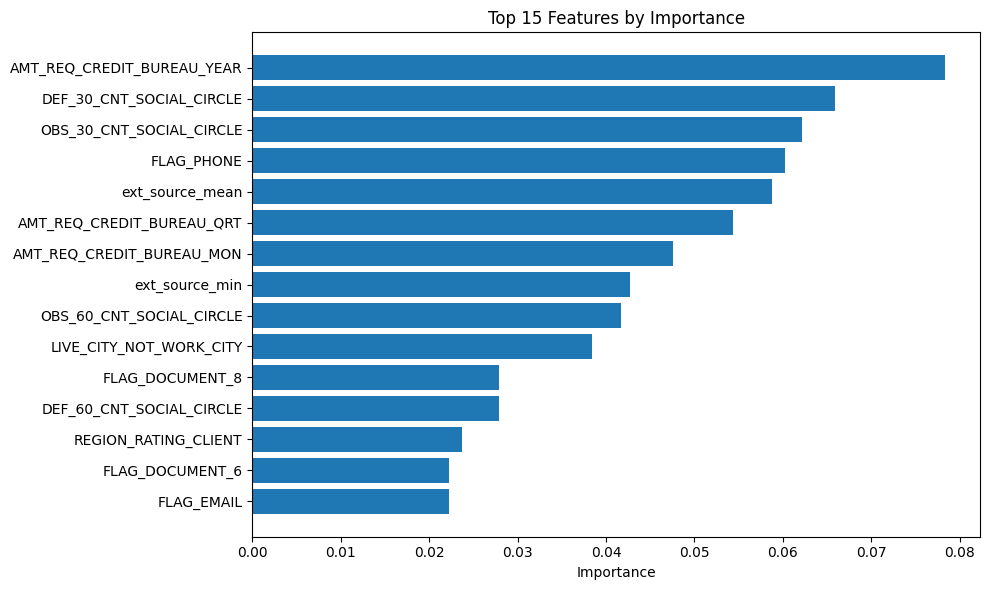

In [38]:
# plot top 15
plt.figure(figsize=(10, 6))
top_15 = importance.head(15)
plt.barh(range(len(top_15)), top_15['importance'].values)
plt.yticks(range(len(top_15)), top_15['feature'].values)
plt.xlabel('Importance')
plt.title('Top 15 Features by Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Threshold Tuning

Default threshold (0.5) might not be optimal. Let's find a better one.

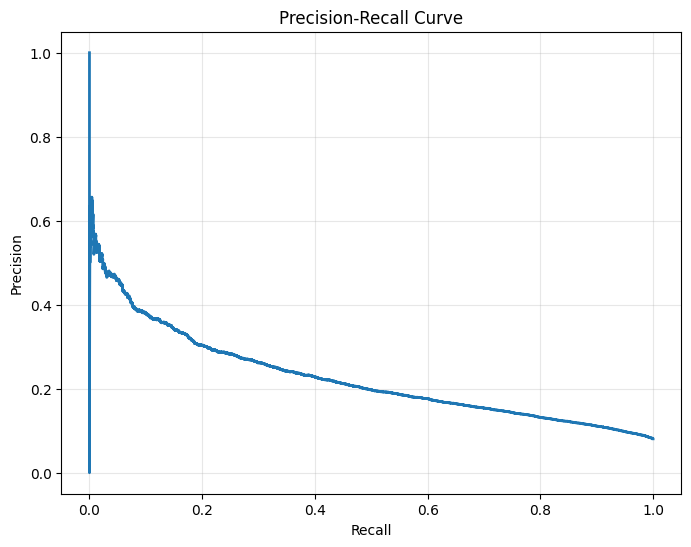

In [39]:
from sklearn.metrics import precision_recall_curve

# get precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_smote)

# plot
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
# find threshold for ~70% recall
target_recall = 0.70

for i in range(len(thresholds)-1, -1, -1):
    if recall[i] >= target_recall and recall[i] <= 0.75:
        best_threshold = thresholds[i]
        best_precision = precision[i]
        best_recall = recall[i]
        break

print(f"Threshold for ~70% recall: {best_threshold:.4f}")
print(f"Precision at this threshold: {best_precision:.4f}")
print(f"Recall at this threshold: {best_recall:.4f}")

Threshold for ~70% recall: 0.5029
Precision at this threshold: 0.1539
Recall at this threshold: 0.7001


In [41]:
# apply threshold
y_pred_tuned = (y_pred_smote >= best_threshold).astype(int)

print("\nClassification report with tuned threshold:")
print(classification_report(y_test, y_pred_tuned, target_names=['Non-Default', 'Default']))


Classification report with tuned threshold:
              precision    recall  f1-score   support

 Non-Default       0.96      0.66      0.78     56538
     Default       0.15      0.70      0.25      4965

    accuracy                           0.67     61503
   macro avg       0.56      0.68      0.52     61503
weighted avg       0.90      0.67      0.74     61503



## 10. Risk Segmentation

Create risk tiers for business use

In [42]:
# check probability distribution first
print("Probability distribution:")
print(pd.Series(y_pred_smote).describe())
print("\nPercentiles:")
for p in [25, 50, 75]:
    print(f"{p}th: {np.percentile(y_pred_smote, p):.4f}")

Probability distribution:
count    61503.000000
mean         0.430803
std          0.214446
min          0.006258
25%          0.256241
50%          0.412973
75%          0.595727
max          0.961007
dtype: float64

Percentiles:
25th: 0.2562
50th: 0.4130
75th: 0.5957


In [43]:
# define risk tiers based on distribution
# goal: ~60% low risk (auto-approve), ~25% medium (review), ~15% high (decline)

def assign_risk_tier(prob):
    if prob < 0.30:
        return 'Low Risk'
    elif prob < 0.60:
        return 'Medium Risk'
    else:
        return 'High Risk'

risk_tiers = pd.Series([assign_risk_tier(p) for p in y_pred_smote])

# summary
print("Risk tier distribution:")
print(risk_tiers.value_counts(normalize=True).sort_index() * 100)

Risk tier distribution:
High Risk      24.484984
Low Risk       32.216315
Medium Risk    43.298701
Name: proportion, dtype: float64


In [46]:
# default rate by tier
print("\nDefault rate by tier:")
for tier in ['Low Risk', 'Medium Risk', 'High Risk']:
    mask = risk_tiers == tier
    # use .values to avoid index mismatch
    default_rate = y_test.values[mask.values].mean()
    count = mask.sum()
    pct = count / len(risk_tiers) * 100
    print(f"{tier:12s}: {pct:5.1f}% of applicants, {default_rate:6.2%} default rate")


Default rate by tier:
Low Risk    :  32.2% of applicants,  2.21% default rate
Medium Risk :  43.3% of applicants,  6.58% default rate
High Risk   :  24.5% of applicants, 18.42% default rate


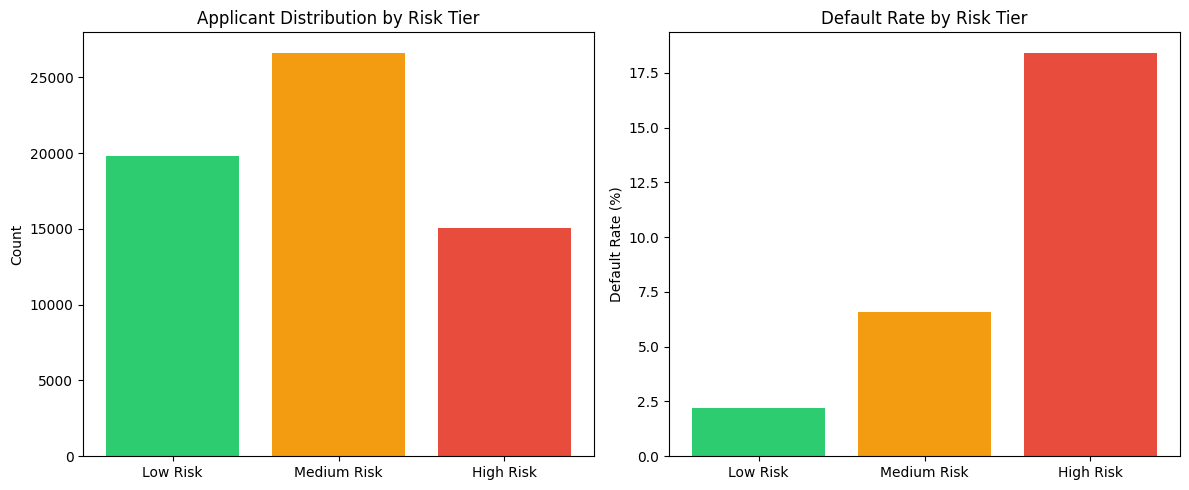

In [47]:
# visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# tier distribution
tier_counts = risk_tiers.value_counts()[['Low Risk', 'Medium Risk', 'High Risk']]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(range(3), tier_counts.values, color=colors)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(tier_counts.index)
axes[0].set_ylabel('Count')
axes[0].set_title('Applicant Distribution by Risk Tier')

# default rate by tier - use .values to avoid index issues
default_rates = []
for tier in ['Low Risk', 'Medium Risk', 'High Risk']:
    mask = risk_tiers == tier
    default_rates.append(y_test.values[mask.values].mean() * 100)

axes[1].bar(range(3), default_rates, color=colors)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['Low Risk', 'Medium Risk', 'High Risk'])
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_title('Default Rate by Risk Tier')

plt.tight_layout()
plt.show()

## Summary

**Model Performance:**
- Logistic Regression: 0.735 AUC
- XGBoost: 0.758 AUC (best)
- XGBoost + SMOTE: 0.744 AUC, 70% recall

**Key Findings:**
1. External credit scores (EXT_SOURCE) are strongest predictors
2. SMOTE improved recall but reduced AUC slightly - acceptable trade-off
3. Risk tiers: 32% Low / 43% Medium / 25% High
4. Can automate 57% of decisions (approve low, decline high)

**Next Steps:**
- Add categorical features
- Try feature selection
- Hyperparameter tuning
- Deploy as API

In [ ]:
# save final model
import pickle

with open('../models/xgb_smote_model.pkl', 'wb') as f:
    pickle.dump(xgb_smote, f)

print("Model saved!")